# Ejercicios Practicos: Arquitectura Transformer

**Curso:** Deep Learning
**Material complementario a:** Infografia "Historia, Intuicion y Matematica del Transformer" (Capitulos 1 a 13)

Este notebook contiene un ejercicio practico por cada capitulo de la infografia. Todas las implementaciones se hacen **desde cero usando NumPy**, sin frameworks de alto nivel (PyTorch/TensorFlow), para reforzar la comprension matematica de cada componente antes de usarlos como cajas negras.

Estructura de cada capitulo:
1. Celda de texto: idea central + que vamos a programar.
2. Celda de codigo: implementacion + impresion de resultados.
3. "Ejercicio propuesto": una variacion para que el estudiante modifique el codigo.

No es necesario instalar nada adicional, solo se usan `numpy` y `matplotlib`, ya disponibles en Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def softmax(x, axis=-1):
    """Softmax numericamente estable a lo largo del eje indicado."""
    x_max = np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

print("Entorno listo. NumPy version:", np.__version__)

Entorno listo. NumPy version: 2.2.6


---
## Capitulo 1 - RNN: El viejo bibliotecario

**Idea central:** la RNN procesa la secuencia palabra por palabra y actualiza una memoria (`h_t`) en cada paso:

`h_t = f(W_h h_{t-1} + W_x x_t + b)`

Cada nuevo estado depende del anterior, por eso la informacion de las primeras palabras se va "diluyendo" cuando la secuencia es larga (el bibliotecario olvida el inicio del libro).

**Vamos a programar:** una RNN simple que procesa la oracion `"Juan estudia inteligencia artificial"` palabra por palabra, e inspeccionamos como cambia la memoria en cada paso.

In [2]:
# Vocabulario de juguete: cada palabra como un vector de embedding aleatorio
vocab = ["Juan", "estudia", "inteligencia", "artificial"]
d_emb = 4   # dimension del embedding
d_hidden = 3  # dimension de la memoria oculta

embeddings = {palabra: np.random.randn(d_emb) for palabra in vocab}

# Parametros de la RNN (compartidos en todos los pasos de tiempo)
W_h = np.random.randn(d_hidden, d_hidden) * 0.5
W_x = np.random.randn(d_hidden, d_emb) * 0.5
b = np.zeros(d_hidden)

def rnn_step(h_prev, x_t):
    return np.tanh(W_h @ h_prev + W_x @ x_t + b)

h = np.zeros(d_hidden)  # memoria inicial
historial = [h.copy()]

for palabra in vocab:
    x_t = embeddings[palabra]
    h = rnn_step(h, x_t)
    historial.append(h.copy())
    print(f"Despues de leer '{palabra}': h = {np.round(h, 3)}")

print("\nMemoria final (resumen de toda la oracion):", np.round(h, 3))

Despues de leer 'Juan': h = [-0.225  0.507 -0.505]
Despues de leer 'estudia': h = [ 0.545  0.973 -0.796]
Despues de leer 'inteligencia': h = [-0.047 -0.102  0.243]
Despues de leer 'artificial': h = [ 0.695 -0.808  0.084]

Memoria final (resumen de toda la oracion): [ 0.695 -0.808  0.084]


**Ejercicio propuesto:** mide cuanto "sobrevive" la informacion de la primera palabra en la memoria final. Para eso, calcula la memoria final dejando `embeddings["Juan"]` igual a cero vs. su valor original, y compara la diferencia en la memoria final para una oracion corta (4 palabras) y una oracion larga (repite una palabra cualquiera 20 veces). Comenta que observas: ¿la diferencia se reduce a medida que la secuencia es mas larga?

In [3]:
# Espacio para el ejercicio propuesto
# Sugerencia: define una funcion run_rnn(secuencia) que reciba una lista de vectores
# y devuelva la memoria final, y compara con/sin el aporte de la primera palabra.

def run_rnn(secuencia_embeddings):
    h = np.zeros(d_hidden)
    for x_t in secuencia_embeddings:
        h = rnn_step(h, x_t)
    return h

# TODO: completar el experimento descrito en el enunciado
# Embedding original de "Juan"
emb_juan_original = embeddings["Juan"].copy()
emb_juan_cero     = np.zeros(d_emb)

def medir_influencia(n_repeticiones_extra=0):
    """
    Construye la secuencia [Juan, estudia, inteligencia, artificial]
    más n_repeticiones_extra palabras de relleno.
    Compara la memoria final con/sin el aporte de 'Juan'.
    """
    relleno = [embeddings["estudia"]] * n_repeticiones_extra
    
    # Con Juan real
    seq_con = [embeddings["Juan"]] + [embeddings[p] for p in vocab[1:]] + relleno
    h_con   = run_rnn(seq_con)
    
    # Con Juan = cero vector (eliminamos su contribucion)
    seq_sin = [emb_juan_cero] + [embeddings[p] for p in vocab[1:]] + relleno
    h_sin   = run_rnn(seq_sin)
    
    diferencia = np.linalg.norm(h_con - h_sin)
    return diferencia

print("Influencia de 'Juan' en secuencia corta (4 palabras):", 
      round(medir_influencia(0), 4))
print("Influencia de 'Juan' en secuencia larga  (24 palabras):", 
      round(medir_influencia(20), 4))


Influencia de 'Juan' en secuencia corta (4 palabras): 0.1403
Influencia de 'Juan' en secuencia larga  (24 palabras): 0.0


---
## Capitulo 2 - LSTM/GRU: Los ayudantes con mejor memoria

**Idea central:** la celda de memoria `C_t` se actualiza con compuertas que deciden que olvidar y que agregar:

`C_t = f_t * C_{t-1} + i_t * C_tilde_t`

- `f_t` (forget gate): cuanto de la memoria anterior se conserva.
- `i_t` (input gate): cuanto de la nueva informacion candidata se agrega.

**Vamos a programar:** una celda LSTM simplificada de un solo paso, y comparamos que pasa con la memoria a lo largo de muchos pasos cuando la compuerta de olvido es alta (cercana a 1) vs. baja (cercana a 0).

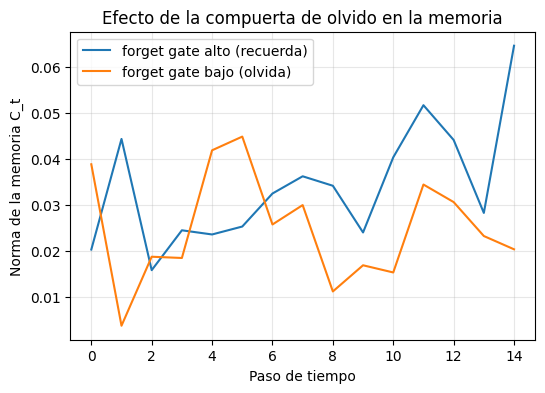

In [4]:
def lstm_cell_step(C_prev, h_prev, x_t, Wf, Wi, Wc, bf, bi, bc):
    """Un paso simplificado de LSTM (sin compuerta de salida, para mantenerlo simple)."""
    entrada = np.concatenate([h_prev, x_t])
    f_t = sigmoid(Wf @ entrada + bf)        # compuerta de olvido
    i_t = sigmoid(Wi @ entrada + bi)        # compuerta de entrada
    C_tilde = np.tanh(Wc @ entrada + bc)    # candidato de nueva informacion
    C_t = f_t * C_prev + i_t * C_tilde      # actualizacion de la memoria
    h_t = np.tanh(C_t)
    return C_t, h_t, f_t, i_t

d_in = d_hidden + d_emb
Wf = np.random.randn(d_hidden, d_in) * 0.3
Wi = np.random.randn(d_hidden, d_in) * 0.3
Wc = np.random.randn(d_hidden, d_in) * 0.3
bf, bi, bc = np.zeros(d_hidden), np.zeros(d_hidden), np.zeros(d_hidden)

def simular_memoria(forget_bias, pasos=15):
    """Simula la evolucion de C_t fijando un sesgo en la compuerta de olvido."""
    C, h = np.zeros(d_hidden), np.zeros(d_hidden)
    norma_memoria = []
    for t in range(pasos):
        x_t = np.random.randn(d_emb) * 0.1  # entradas pequenas/ruido, casi no aportan info nueva
        C, h, f_t, i_t = lstm_cell_step(C, h, x_t, Wf, Wi, Wc, bf + forget_bias, bi, bc)
        norma_memoria.append(np.linalg.norm(C))
    return norma_memoria

memoria_alta = simular_memoria(forget_bias=3.0)   # forget gate ~ cercano a 1 -> recuerda mas
memoria_baja = simular_memoria(forget_bias=-3.0)  # forget gate ~ cercano a 0 -> olvida rapido

plt.figure(figsize=(6, 4))
plt.plot(memoria_alta, label="forget gate alto (recuerda)")
plt.plot(memoria_baja, label="forget gate bajo (olvida)")
plt.xlabel("Paso de tiempo")
plt.ylabel("Norma de la memoria C_t")
plt.title("Efecto de la compuerta de olvido en la memoria")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Ejercicio propuesto:** modifica `forget_bias` a un valor intermedio (por ejemplo, 0.0) y agrega esa curva al grafico. ¿El comportamiento es gradual entre los dos extremos? Comenta en una celda de texto que rol cumple `forget_bias` en una LSTM real entrenada (¿quien decide su valor?).

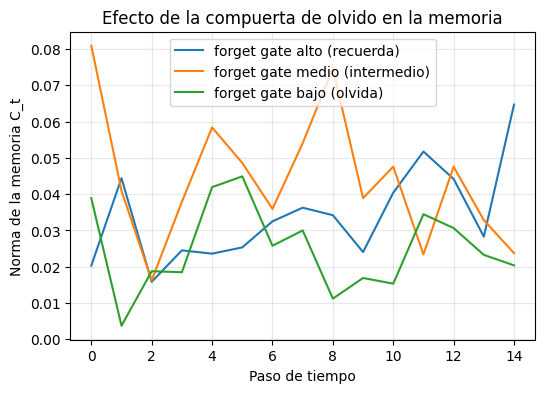

In [5]:
memoria_media = simular_memoria(forget_bias=0.0)

plt.figure(figsize=(6, 4))
plt.plot(memoria_alta, label="forget gate alto (recuerda)")
plt.plot(memoria_media, label="forget gate medio (intermedio)")
plt.plot(memoria_baja,  label="forget gate bajo (olvida)")
plt.xlabel("Paso de tiempo")
plt.ylabel("Norma de la memoria C_t")
plt.title("Efecto de la compuerta de olvido en la memoria")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Capitulo 3 - La llegada de Attention

**Idea central:** en lugar de usar toda la memoria por igual, Attention calcula un vector de contexto como una suma ponderada de representaciones `h_i`, usando pesos `alpha_i` que indican que tan relevante es cada palabra:

`c_t = sum_i ( alpha_i * h_i )`,  con `0 <= alpha_i <= 1` y `sum_i alpha_i = 1`

**Vamos a programar:** replicamos el ejemplo de la infografia (`Juan estudia inteligencia artificial`, con pesos `0.05, 0.15, 0.40, 0.40`) calculando el vector de contexto, y luego calculamos los pesos `alpha_i` a partir de unos puntajes (scores) sin procesar, usando softmax.

In [6]:
h_vectores = np.array([embeddings[p] for p in vocab])  # una fila por palabra
alpha_dados = np.array([0.05, 0.15, 0.40, 0.40])  # pesos del ejemplo de la infografia

assert np.isclose(alpha_dados.sum(), 1.0), "Los pesos de atencion deben sumar 1"

contexto = alpha_dados @ h_vectores  # suma ponderada: (4,) @ (4, d_emb) -> (d_emb,)
print("Vector de contexto (pesos dados):", np.round(contexto, 3))

# Ahora, en la practica los pesos NO se dan directamente: se calculan a partir de scores
# crudos (por ejemplo, que tan relacionada esta cada palabra con una pregunta) usando softmax
scores_crudos = np.array([0.2, 1.1, 2.8, 2.9])  # scores de ejemplo (sin normalizar)
alpha_calculado = softmax(scores_crudos)
print("\nPesos calculados con softmax:", np.round(alpha_calculado, 3))
print("Suma de los pesos:", alpha_calculado.sum())

contexto_calculado = alpha_calculado @ h_vectores
print("\nVector de contexto (pesos calculados):", np.round(contexto_calculado, 3))

Vector de contexto (pesos dados): [-0.101 -0.59  -0.606 -0.22 ]

Pesos calculados con softmax: [0.031 0.077 0.423 0.468]
Suma de los pesos: 0.9999999999999999

Vector de contexto (pesos calculados): [-0.088 -0.688 -0.861 -0.353]


**Ejercicio propuesto:** cambia `scores_crudos` para que una sola palabra concentre casi toda la atencion (por ejemplo, `[0.0, 0.0, 6.0, 0.0]`). Observa como el vector de contexto resultante se parece mucho al embedding de esa palabra. Explica con tus palabras por que ocurre esto.

In [7]:
# TODO: probar con un score muy concentrado en una sola palabra y comparar
# el vector de contexto resultante contra embeddings["inteligencia"], por ejemplo.
# Ejercicio: score muy concentrado en una sola palabra
scores_concentrados = np.array([0.0, 0.0, 6.0, 0.0])
alpha_concentrado = softmax(scores_concentrados)
contexto_concentrado = alpha_concentrado @ h_vectores

print("Pesos:", np.round(alpha_concentrado, 4))
print("Contexto concentrado:", np.round(contexto_concentrado, 3))
print("Embedding de 'inteligencia':", np.round(embeddings["inteligencia"], 3))
print("Distancia entre ambos:", np.linalg.norm(contexto_concentrado - embeddings["inteligencia"]))

Pesos: [0.0025 0.0025 0.9926 0.0025]
Contexto concentrado: [-0.465  0.533 -0.459 -0.458]
Embedding de 'inteligencia': [-0.469  0.543 -0.463 -0.466]
Distancia entre ambos: 0.013988341728227245


---
## Capitulo 4 - Los tres guardianes del conocimiento (Query, Key, Value)

**Idea central:** a partir de los embeddings `X`, se proyectan tres matrices distintas usando pesos entrenables:

`Q = X W_Q`,  `K = X W_K`,  `V = X W_V`

- Query: que busco.
- Key: donde puede estar la informacion.
- Value: la informacion en si.

**Vamos a programar:** las proyecciones Q, K y V para la oracion de ejemplo, y verificamos las dimensiones resultantes.

In [8]:
X = h_vectores  # embeddings de entrada: (n_palabras, d_emb) = (4, 4)
d_k = 5  # dimension elegida para Q, K, V (puede ser distinta a d_emb)

W_Q = np.random.randn(d_emb, d_k) * 0.5
W_K = np.random.randn(d_emb, d_k) * 0.5
W_V = np.random.randn(d_emb, d_k) * 0.5

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("X (embeddings de entrada):", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("\nQ (query de cada palabra):\n", np.round(Q, 2))

X (embeddings de entrada): (4, 4)
Q: (4, 5)
K: (4, 5)
V: (4, 5)

Q (query de cada palabra):
 [[-0.43  0.7   0.4   0.57  1.17]
 [-0.21 -0.1  -0.6   1.09  0.35]
 [-0.35 -0.29 -0.15 -0.02 -0.9 ]
 [ 2.26  0.4   0.05 -1.38  0.37]]


**Ejercicio propuesto:** cambia `d_k` a 2 y a 8, vuelve a correr la celda y confirma que las formas de `Q`, `K`, `V` cambian de manera consistente. ¿Que forma NO cambia nunca, sin importar el valor de `d_k`? ¿Por que?

In [9]:
# TODO: probar con d_k = 2 y d_k = 8, e imprimir las formas resultantes en cada caso
X = h_vectores  # embeddings de entrada: (n_palabras, d_emb) = (4, 4)
d_k = 2  # dimension elegida para Q, K, V (puede ser distinta a d_emb)

W_Q = np.random.randn(d_emb, d_k) * 0.5
W_K = np.random.randn(d_emb, d_k) * 0.5
W_V = np.random.randn(d_emb, d_k) * 0.5

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("X (embeddings de entrada):", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("\nQ (query de cada palabra):\n", np.round(Q, 2))


X (embeddings de entrada): (4, 4)
Q: (4, 2)
K: (4, 2)
V: (4, 2)

Q (query de cada palabra):
 [[-1.48 -0.9 ]
 [-0.86 -0.33]
 [ 0.71  0.08]
 [ 0.48  0.71]]


In [10]:
X = h_vectores  # embeddings de entrada: (n_palabras, d_emb) = (4, 4)
d_k = 8  # dimension elegida para Q, K, V (puede ser distinta a d_emb)

W_Q = np.random.randn(d_emb, d_k) * 0.5
W_K = np.random.randn(d_emb, d_k) * 0.5
W_V = np.random.randn(d_emb, d_k) * 0.5

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("X (embeddings de entrada):", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("\nQ (query de cada palabra):\n", np.round(Q, 2))

X (embeddings de entrada): (4, 4)
Q: (4, 8)
K: (4, 8)
V: (4, 8)

Q (query de cada palabra):
 [[ 0.52 -0.8  -1.47  0.26 -1.29  1.24  0.86  0.43]
 [-0.55 -0.76 -2.3  -0.14 -1.22  0.89  0.46  1.34]
 [ 0.2   0.63  1.23 -0.2   0.7  -0.23  0.23 -0.66]
 [-0.85 -0.29  0.05  1.05  0.2  -0.91 -2.72 -0.65]]


---
## Capitulo 5 - El observador universal (Self-Attention)

**Idea central:** cada palabra "mira" a todas las demas para entender el contexto, calculando:

`Score = Q K^T`,  luego `Attention(Q, K, V) = softmax(Score / sqrt(d_k)) V`

**Vamos a programar:** self-attention completo sobre la oracion `"Juan fue al banco a retirar dinero"`, y visualizamos la matriz de atencion para confirmar que `banco` se relaciona fuertemente con `retirar` y `dinero`.

Forma de la matriz de atencion: (7, 7)
Forma de la salida: (7, 6)


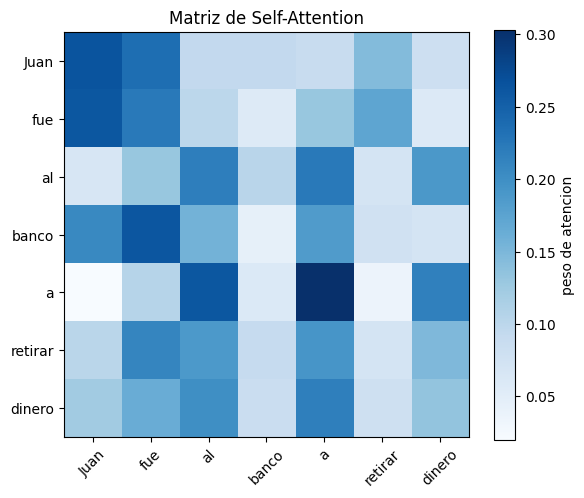


Pesos de atencion de 'banco' hacia cada palabra:
  Juan      : 0.207
  fue       : 0.262
  al        : 0.156
  banco     : 0.044
  a         : 0.185
  retirar   : 0.076
  dinero    : 0.071


In [11]:
palabras_banco = ["Juan", "fue", "al", "banco", "a", "retirar", "dinero"]
d_emb2 = 6
d_k2 = 6

# Para que el ejemplo sea ilustrativo, forzamos a que 'banco', 'retirar' y 'dinero'
# tengan embeddings parecidos entre si (simulando que el modelo ya aprendio esa relacion semantica)
np.random.seed(7)
emb_banco = {p: np.random.randn(d_emb2) for p in palabras_banco}
vector_base_finanzas = np.random.randn(d_emb2)
for p in ["banco", "retirar", "dinero"]:
    emb_banco[p] = emb_banco[p] * 0.3 + vector_base_finanzas * 0.7

X2 = np.array([emb_banco[p] for p in palabras_banco])

W_Q2 = np.random.randn(d_emb2, d_k2) * 0.5
W_K2 = np.random.randn(d_emb2, d_k2) * 0.5
W_V2 = np.random.randn(d_emb2, d_k2) * 0.5

Q2, K2, V2 = X2 @ W_Q2, X2 @ W_K2, X2 @ W_V2

scores = (Q2 @ K2.T) / np.sqrt(d_k2)
pesos_atencion = softmax(scores, axis=-1)
salida = pesos_atencion @ V2

print("Forma de la matriz de atencion:", pesos_atencion.shape)
print("Forma de la salida:", salida.shape)

plt.figure(figsize=(6, 5))
plt.imshow(pesos_atencion, cmap="Blues")
plt.xticks(range(len(palabras_banco)), palabras_banco, rotation=45)
plt.yticks(range(len(palabras_banco)), palabras_banco)
plt.colorbar(label="peso de atencion")
plt.title("Matriz de Self-Attention")
plt.tight_layout()
plt.show()

idx_banco = palabras_banco.index("banco")
print("\nPesos de atencion de 'banco' hacia cada palabra:")
for palabra, peso in zip(palabras_banco, pesos_atencion[idx_banco]):
    print(f"  {palabra:10s}: {peso:.3f}")

**Ejercicio propuesto:** identifica en el grafico cual es la palabra a la que `banco` le presta MAS atencion (fuera de si misma). Luego, repite el experimento sin forzar la similitud semantica (usa embeddings totalmente aleatorios e independientes) y compara: ¿la relacion `banco-retirar-dinero` se mantiene o desaparece?

In [12]:
# TODO: repetir el calculo de self-attention con embeddings totalmente aleatorios
# (sin la mezcla con vector_base_finanzas) y comparar los pesos de atencion de 'banco'

def softmax(x, axis=-1):
    x_max = np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

palabras_banco = ['Juan', 'fue', 'al', 'banco', 'a', 'retirar', 'dinero']
d_emb2 = 6
d_k2 = 6

# Version CON mezcla semantica forzada (como el notebook original)
np.random.seed(7)
emb_banco_con = {p: np.random.randn(d_emb2) for p in palabras_banco}
vector_base_finanzas = np.random.randn(d_emb2)
for p in ['banco', 'retirar', 'dinero']:
    emb_banco_con[p] = emb_banco_con[p] * 0.3 + vector_base_finanzas * 0.7
X_con = np.array([emb_banco_con[p] for p in palabras_banco])

# Version SIN mezcla - embeddings totalmente independientes
np.random.seed(7)
emb_banco_sin = {p: np.random.randn(d_emb2) for p in palabras_banco}
X_sin = np.array([emb_banco_sin[p] for p in palabras_banco])

# Usamos LA MISMA semilla para W_Q, W_K, W_V en ambos casos para comparar limpio
np.random.seed(42)
W_Q2 = np.random.randn(d_emb2, d_k2) * 0.5
W_K2 = np.random.randn(d_emb2, d_k2) * 0.5
W_V2 = np.random.randn(d_emb2, d_k2) * 0.5

def calcular_pesos(X):
    Q, K = X @ W_Q2, X @ W_K2
    scores = (Q @ K.T) / np.sqrt(d_k2)
    return softmax(scores, axis=-1)

pesos_con = calcular_pesos(X_con)
pesos_sin = calcular_pesos(X_sin)

idx_banco = palabras_banco.index('banco')

print('CON mezcla semantica forzada:')
for palabra, peso in zip(palabras_banco, pesos_con[idx_banco]):
    print(f'  banco -> {palabra:10s}: {peso:.3f}')

print()
print('SIN mezcla (embeddings independientes):')
for palabra, peso in zip(palabras_banco, pesos_sin[idx_banco]):
    print(f'  banco -> {palabra:10s}: {peso:.3f}')


CON mezcla semantica forzada:
  banco -> Juan      : 0.006
  banco -> fue       : 0.016
  banco -> al        : 0.021
  banco -> banco     : 0.224
  banco -> a         : 0.037
  banco -> retirar   : 0.521
  banco -> dinero    : 0.174

SIN mezcla (embeddings independientes):
  banco -> Juan      : 0.083
  banco -> fue       : 0.037
  banco -> al        : 0.259
  banco -> banco     : 0.049
  banco -> a         : 0.272
  banco -> retirar   : 0.033
  banco -> dinero    : 0.266


---
## Capitulo 6 - El problema del orden

**Idea central:** sin informacion de posicion, self-attention es invariante a permutaciones: `Atencion(X) = Atencion(permuta(X))`. Esto significa que el modelo, por si solo, no distingue `"el perro mordio al hombre"` de `"el hombre mordio al perro"` si ambas usan las mismas palabras.

**Vamos a programar:** verificamos numericamente que al permutar el orden de las filas de entrada, la salida de self-attention se permuta exactamente igual (sin alterar los valores), confirmando que el contenido importa pero el orden, todavia no.

In [13]:
def self_attention(X, W_Q, W_K, W_V):
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d)
    pesos = softmax(scores, axis=-1)
    return pesos @ V

# Usamos las mismas 4 palabras del capitulo 1, en dos ordenes distintos
orden_original = ["Juan", "estudia", "inteligencia", "artificial"]
permutacion = [3, 1, 0, 2]  # un reordenamiento arbitrario de los indices
orden_permutado = [orden_original[i] for i in permutacion]

X_original = np.array([embeddings[p] for p in orden_original])
X_permutado = np.array([embeddings[p] for p in orden_permutado])

W_Qc, W_Kc, W_Vc = (np.random.randn(d_emb, d_k) * 0.5 for _ in range(3))

salida_original = self_attention(X_original, W_Qc, W_Kc, W_Vc)
salida_permutada = self_attention(X_permutado, W_Qc, W_Kc, W_Vc)

# Si reordenamos la salida_original con la misma permutacion, deberia coincidir con salida_permutada
salida_original_reordenada = salida_original[permutacion]

print("¿La salida permutada coincide con reordenar la salida original?")
print(np.allclose(salida_original_reordenada, salida_permutada, atol=1e-10))

¿La salida permutada coincide con reordenar la salida original?
True


**Ejercicio propuesto:** prueba con otra permutacion distinta (por ejemplo, invertir el orden de las 4 palabras) y confirma que la propiedad se sigue cumpliendo. Escribe en una celda de texto, con tus propias palabras, por que esto es un problema para tareas de lenguaje natural.

In [14]:
# TODO: probar con la permutacion [3, 2, 1, 0] (orden invertido) y verificar la propiedad
def self_attention(X, W_Q, W_K, W_V):
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d)
    pesos = softmax(scores, axis=-1)
    return pesos @ V

# Usamos las mismas 4 palabras del capitulo 1, en dos ordenes distintos
orden_original = ["estudia", "inteligencia", "Juan", "artificial"]
permutacion = [3, 1, 0, 2]  # un reordenamiento arbitrario de los indices
orden_permutado = [orden_original[i] for i in permutacion]

X_original = np.array([embeddings[p] for p in orden_original])
X_permutado = np.array([embeddings[p] for p in orden_permutado])

W_Qc, W_Kc, W_Vc = (np.random.randn(d_emb, d_k) * 0.5 for _ in range(3))

salida_original = self_attention(X_original, W_Qc, W_Kc, W_Vc)
salida_permutada = self_attention(X_permutado, W_Qc, W_Kc, W_Vc)

# Si reordenamos la salida_original con la misma permutacion, deberia coincidir con salida_permutada
salida_original_reordenada = salida_original[permutacion]

print("¿La salida permutada coincide con reordenar la salida original?")
print(np.allclose(salida_original_reordenada, salida_permutada, atol=1e-10))

¿La salida permutada coincide con reordenar la salida original?
True


---
## Capitulo 7 - El numerador de palabras (Positional Encoding)

**Idea central:** se suma un vector de posicion a cada embedding usando funciones seno/coseno de distinta frecuencia por dimension:

`PE(pos, 2i) = sin(pos / 10000^(2i/d_model))`
`PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))`

`X_final = X_embedding + PE`

**Vamos a programar:** la matriz de positional encoding, la visualizamos, y repetimos el experimento del Capitulo 6 sumando la posicion: ahora el orden si debe importar.

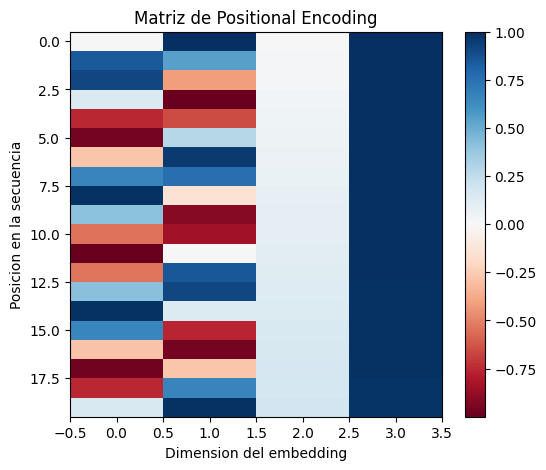

¿Con positional encoding, la salida sigue siendo solo una permutacion simple?
False


In [15]:
def positional_encoding(n_posiciones, d_model):
    PE = np.zeros((n_posiciones, d_model))
    posiciones = np.arange(n_posiciones)[:, np.newaxis]       # (n_pos, 1)
    dims = np.arange(d_model)[np.newaxis, :]                  # (1, d_model)
    angulos = posiciones / np.power(10000, (2 * (dims // 2)) / d_model)
    PE[:, 0::2] = np.sin(angulos[:, 0::2])  # indices pares -> seno
    PE[:, 1::2] = np.cos(angulos[:, 1::2])  # indices impares -> coseno
    return PE

n_pos, d_model = 20, d_emb
PE = positional_encoding(n_pos, d_model)

plt.figure(figsize=(6, 5))
plt.imshow(PE, cmap="RdBu", aspect="auto")
plt.xlabel("Dimension del embedding")
plt.ylabel("Posicion en la secuencia")
plt.title("Matriz de Positional Encoding")
plt.colorbar()
plt.show()

# Repetimos el experimento del Capitulo 6, ahora sumando PE segun la posicion real
X_original_pe = X_original + PE[:4]
X_permutado_pe = X_permutado + PE[:4]  # misma PE por POSICION, no por palabra

salida_original_pe = self_attention(X_original_pe, W_Qc, W_Kc, W_Vc)
salida_permutada_pe = self_attention(X_permutado_pe, W_Qc, W_Kc, W_Vc)
salida_original_pe_reordenada = salida_original_pe[permutacion]

print("¿Con positional encoding, la salida sigue siendo solo una permutacion simple?")
print(np.allclose(salida_original_pe_reordenada, salida_permutada_pe, atol=1e-10))

**Ejercicio propuesto:** el resultado de la ultima celda deberia dar `False`. Explica por que ahora ya NO se cumple la igualdad (a diferencia del Capitulo 6), relacionandolo con que es lo que cambio en `X_original_pe` vs `X_permutado_pe`.

# TODO: escribir, en una celda de texto o como comentario, la explicacion solicitada
Porque ahora le hemos puesto una posicion a cada uno. entonces cada palabra tendrá su propio posicional encoding.

---
## Capitulo 8 - El consejo de expertos (Multi-Head Attention)

**Idea central:** en lugar de una sola atencion, varias "cabezas" trabajan en paralelo, cada una mirando un subespacio distinto de Q, K, V. Al final se concatenan y se proyectan con `W_O`:

`head_i = Attention(Q_i, K_i, V_i)` para `i = 1, ..., h`
`MultiHead(Q,K,V) = Concat(head_1, ..., head_h) W_O`

**Vamos a programar:** multi-head attention dividiendo `d_model` en `h` cabezas iguales, sobre la oracion del banco.

In [16]:
def multi_head_attention(X, n_heads, d_model):
    assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
    d_cabeza = d_model // n_heads

    W_Q = np.random.randn(d_model, d_model) * 0.3
    W_K = np.random.randn(d_model, d_model) * 0.3
    W_V = np.random.randn(d_model, d_model) * 0.3
    W_O = np.random.randn(d_model, d_model) * 0.3

    Q, K, V = X @ W_Q, X @ W_K, X @ W_V  # (n_palabras, d_model)

    n_palabras = X.shape[0]
    cabezas_salida = []
    for h in range(n_heads):
        inicio, fin = h * d_cabeza, (h + 1) * d_cabeza
        Qh, Kh, Vh = Q[:, inicio:fin], K[:, inicio:fin], V[:, inicio:fin]
        scores_h = (Qh @ Kh.T) / np.sqrt(d_cabeza)
        pesos_h = softmax(scores_h, axis=-1)
        cabezas_salida.append(pesos_h @ Vh)

    concatenado = np.concatenate(cabezas_salida, axis=-1)  # (n_palabras, d_model)
    salida = concatenado @ W_O
    return salida

salida_mha = multi_head_attention(X2, n_heads=3, d_model=d_emb2)
print("Forma de la entrada X2:", X2.shape)
print("Forma de la salida de Multi-Head Attention:", salida_mha.shape)
print("\nSalida (primeras 2 palabras):\n", np.round(salida_mha[:2], 3))

Forma de la entrada X2: (7, 6)
Forma de la salida de Multi-Head Attention: (7, 6)

Salida (primeras 2 palabras):
 [[ 0.45   0.179 -0.156  0.475  0.14   0.63 ]
 [ 0.449  0.178 -0.138  0.506  0.219  0.587]]


**Ejercicio propuesto:** `d_emb2` vale 6. Prueba `multi_head_attention(X2, n_heads=2, d_model=6)` y `multi_head_attention(X2, n_heads=6, d_model=6)`. ¿Que pasa si intentas `n_heads=4`? Explica por que falla el `assert`.

In [28]:
# TODO: probar con n_heads = 2, n_heads = 6, y luego n_heads = 4 (observar el error)
def multi_head_attention(X, n_heads, d_model):
    assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
    d_cabeza = d_model // n_heads

    W_Q = np.random.randn(d_model, d_model) * 0.3
    W_K = np.random.randn(d_model, d_model) * 0.3
    W_V = np.random.randn(d_model, d_model) * 0.3
    W_O = np.random.randn(d_model, d_model) * 0.3

    Q, K, V = X @ W_Q, X @ W_K, X @ W_V  # (n_palabras, d_model)

    n_palabras = X.shape[0]
    cabezas_salida = []
    for h in range(n_heads):
        inicio, fin = h * d_cabeza, (h + 1) * d_cabeza
        Qh, Kh, Vh = Q[:, inicio:fin], K[:, inicio:fin], V[:, inicio:fin]
        scores_h = (Qh @ Kh.T) / np.sqrt(d_cabeza)
        pesos_h = softmax(scores_h, axis=-1)
        cabezas_salida.append(pesos_h @ Vh)

    concatenado = np.concatenate(cabezas_salida, axis=-1)  # (n_palabras, d_model)
    salida = concatenado @ W_O
    return salida

salida_mha = multi_head_attention(X2, n_heads=2, d_model=d_emb2)
print("Forma de la entrada X2:", X2.shape)
print("Forma de la salida de Multi-Head Attention:", salida_mha.shape)
print("\nSalida (primeras 2 palabras):\n", np.round(salida_mha[:2], 3))

Forma de la entrada X2: (7, 6)
Forma de la salida de Multi-Head Attention: (7, 6)

Salida (primeras 2 palabras):
 [[ 0.338 -0.172  0.169  0.764 -0.298  0.292]
 [ 0.309 -0.205  0.156  0.687 -0.309  0.255]]


In [31]:
def multi_head_attention(X, n_heads, d_model):
    assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
    d_cabeza = d_model // n_heads

    W_Q = np.random.randn(d_model, d_model) * 0.3
    W_K = np.random.randn(d_model, d_model) * 0.3
    W_V = np.random.randn(d_model, d_model) * 0.3
    W_O = np.random.randn(d_model, d_model) * 0.3

    Q, K, V = X @ W_Q, X @ W_K, X @ W_V  # (n_palabras, d_model)

    n_palabras = X.shape[0]
    cabezas_salida = []
    for h in range(n_heads):
        inicio, fin = h * d_cabeza, (h + 1) * d_cabeza
        Qh, Kh, Vh = Q[:, inicio:fin], K[:, inicio:fin], V[:, inicio:fin]
        scores_h = (Qh @ Kh.T) / np.sqrt(d_cabeza)
        pesos_h = softmax(scores_h, axis=-1)
        cabezas_salida.append(pesos_h @ Vh)

    concatenado = np.concatenate(cabezas_salida, axis=-1)  # (n_palabras, d_model)
    salida = concatenado @ W_O
    return salida

salida_mha = multi_head_attention(X2, n_heads=3, d_model=d_emb2)
print("Forma de la entrada X2:", X2.shape)
print("Forma de la salida de Multi-Head Attention:", salida_mha.shape)
print("\nSalida (primeras 2 palabras):\n", np.round(salida_mha[:2], 3))

Forma de la entrada X2: (7, 6)
Forma de la salida de Multi-Head Attention: (7, 6)

Salida (primeras 2 palabras):
 [[-0.149 -0.222 -0.444 -0.065  0.244  0.271]
 [-0.192 -0.273 -0.445 -0.069  0.245  0.26 ]]


---
## Capitulo 9 - Los sabios lectores y el escritor (Encoder-Decoder)

**Idea central:**
- El Encoder lee toda la entrada y produce representaciones `H = Encoder(X)`.
- El Decoder genera la salida palabra por palabra (autoregresivo), usando tanto `H` como lo que ya escribio: `P(y_t | y_1, ..., y_{t-1}, H)`.

**Vamos a programar:** una version de juguete: un "encoder" que resume una oracion de entrada en un vector `H`, y un "decoder" que, paso a paso, elige la siguiente palabra de un vocabulario de salida usando `H` y la ultima palabra generada.

In [18]:
# Vocabulario de salida (toy) y sus embeddings
vocab_salida = ["la", "IA", "es", "util", "<fin>"]
emb_salida = {p: np.random.randn(d_emb) for p in vocab_salida}

def encoder_toy(X):
    """Resume la secuencia de entrada en un unico vector de contexto H (promedio simple)."""
    return X.mean(axis=0)

def decoder_paso(y_prev_emb, H, W_dec):
    """Dado el embedding de la ultima palabra generada y el contexto H,
    calcula un score por cada palabra del vocabulario de salida y elige la de mayor score."""
    entrada = np.concatenate([y_prev_emb, H])
    scores = W_dec @ entrada  # (len(vocab_salida),)
    probs = softmax(scores)
    idx_elegido = np.argmax(probs)
    return vocab_salida[idx_elegido], probs

H = encoder_toy(X_original)  # contexto resumido de "Juan estudia inteligencia artificial"
print("Vector de contexto H:", np.round(H, 3))

W_dec = np.random.randn(len(vocab_salida), d_emb + d_hidden if False else d_emb + d_emb) * 0.3
# nota: H y los embeddings de salida estan en la misma dimension (d_emb) en este ejemplo de juguete

y_actual = np.zeros(d_emb)  # token inicial <inicio>, representado como vector cero
secuencia_generada = []
for paso in range(5):
    palabra, probs = decoder_paso(y_actual, H, W_dec)
    secuencia_generada.append(palabra)
    if palabra == "<fin>":
        break
    y_actual = emb_salida[palabra]

print("\nSecuencia generada por el decoder:", secuencia_generada)

Vector de contexto H: [ 0.009 -0.436  0.01   0.316]

Secuencia generada por el decoder: ['util', 'es', '<fin>']


**Ejercicio propuesto:** este decoder de juguete no esta entrenado, por lo que la secuencia generada es esencialmente aleatoria (depende de los pesos `W_dec` inicializados al azar). Cambia la semilla (`np.random.seed(...)`) antes de crear `W_dec` y vuelve a correr: confirma que la secuencia generada cambia. En un modelo real, ¿que proceso ajusta `W_dec` para que el decoder genere texto coherente?

In [19]:
# TODO: probar con distintas semillas para W_dec y observar como cambia la secuencia generada


---
## Capitulo 10 - El guardian del futuro (Masked Attention)

**Idea central:** al generar texto, el decoder no puede "ver" palabras futuras. Se aplica una mascara causal que pone `-infinito` en las posiciones futuras antes del softmax, de modo que su peso de atencion termine en 0:

`A_mask[i,j] = A[i,j] si j <= i,  -infinito si j > i`

**Vamos a programar:** la mascara causal para una secuencia de 6 posiciones, la aplicamos a una matriz de scores aleatoria, y verificamos que ninguna posicion atiende al futuro.

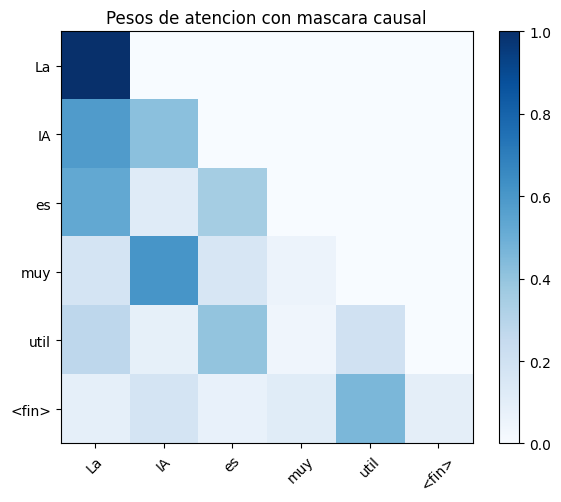

Suma total de atencion puesta en posiciones futuras: 0.0


In [20]:
def mascara_causal(n):
    """Matriz (n, n) con 0 donde esta permitido atender y -inf donde esta prohibido (futuro)."""
    mascara = np.triu(np.ones((n, n)), k=1) * -1e9  # -inf por encima de la diagonal
    return mascara

n_pasos = 6
secuencia_salida = ["La", "IA", "es", "muy", "util", "<fin>"]
scores_aleatorios = np.random.randn(n_pasos, n_pasos)

mascara = mascara_causal(n_pasos)
scores_enmascarados = scores_aleatorios + mascara
pesos_finales = softmax(scores_enmascarados, axis=-1)

plt.figure(figsize=(6, 5))
plt.imshow(pesos_finales, cmap="Blues")
plt.xticks(range(n_pasos), secuencia_salida, rotation=45)
plt.yticks(range(n_pasos), secuencia_salida)
plt.title("Pesos de atencion con mascara causal")
plt.colorbar()
plt.tight_layout()
plt.show()

# Verificacion: la suma de pesos de atencion al futuro debe ser practicamente 0
suma_futuro = sum(pesos_finales[i, i+1:].sum() for i in range(n_pasos))
print("Suma total de atencion puesta en posiciones futuras:", suma_futuro)

**Ejercicio propuesto:** modifica `mascara_causal` para que, ademas de bloquear el futuro, cada posicion tampoco pueda atender a si misma (solo al pasado estricto). Verifica con el mismo tipo de comprobacion que la diagonal tambien queda en 0.

In [21]:
# TODO: crear una variante de mascara_causal donde la diagonal tambien quede bloqueada


---
## Capitulo 11 - La red de refinamiento (Feed Forward Network)

**Idea central:** despues de la atencion, cada posicion se procesa de forma independiente con una red neuronal simple:

`FFN(x) = W2 * relu(W1 x + b1) + b2`

No mira otras posiciones: solo refina la informacion que ya recibio.

**Vamos a programar:** la FFN aplicada posicion por posicion sobre la salida de self-attention del ejemplo del banco (Capitulo 5).

In [22]:
d_ff = 16  # dimension interna (oculta) de la FFN, tipicamente mayor a d_model

W1 = np.random.randn(d_ff, d_k2) * 0.3
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_k2, d_ff) * 0.3
b2 = np.zeros(d_k2)

def ffn(x, W1, b1, W2, b2):
    """Aplica la FFN a una sola posicion (vector x)."""
    return W2 @ relu(W1 @ x + b1) + b2

def ffn_por_posicion(X, W1, b1, W2, b2):
    """Aplica la misma FFN a cada fila (posicion) de X de forma independiente."""
    return np.array([ffn(x, W1, b1, W2, b2) for x in X])

salida_atencion = salida  # viene del Capitulo 5: salida de self-attention sobre 'banco ...'
salida_ffn = ffn_por_posicion(salida_atencion, W1, b1, W2, b2)

print("Forma de entrada a la FFN:", salida_atencion.shape)
print("Forma de salida de la FFN:", salida_ffn.shape)
print("\n¿Misma forma? (la FFN no cambia las dimensiones de la secuencia):",
      salida_atencion.shape == salida_ffn.shape)

Forma de entrada a la FFN: (7, 6)
Forma de salida de la FFN: (7, 6)

¿Misma forma? (la FFN no cambia las dimensiones de la secuencia): True


**Ejercicio propuesto:** verifica de forma practica que la FFN procesa cada posicion de forma independiente: cambia solo la fila correspondiente a `"dinero"` en `salida_atencion` (por ejemplo, multiplicala por 10) y confirma que las filas de salida de las DEMAS palabras no cambian en absoluto.

In [23]:
# TODO: modificar una sola fila de salida_atencion y verificar que las demas filas de
# salida_ffn permanecen identicas


---
## Capitulo 12 - Las conexiones de respaldo y el equilibrio

**Idea central:** dos mecanismos protegen el entrenamiento:

1. Conexion residual: `y = x + Sublayer(x)` (un atajo que evita perder la informacion original).
2. Layer Normalization: `LayerNorm(x) = ((x - mu) / sqrt(sigma^2 + eps)) * gamma + beta` (mantiene los valores en un rango estable).

**Vamos a programar:** ambos mecanismos, y comparamos las estadisticas (media, desviacion estandar) antes y despues de aplicarlos.

In [24]:
def layer_norm(x, gamma, beta, eps=1e-5):
    """Normaliza un vector x para que tenga media 0 y varianza 1, luego reescala con gamma/beta."""
    mu = x.mean()
    sigma2 = x.var()
    x_norm = (x - mu) / np.sqrt(sigma2 + eps)
    return gamma * x_norm + beta

gamma = np.ones(d_k2)
beta = np.zeros(d_k2)

# Sublayer = FFN del capitulo anterior, aplicada sobre la salida de atencion
sublayer_salida = salida_ffn

# 1) Conexion residual
y_residual = salida_atencion + sublayer_salida

# 2) Layer normalization, aplicada por posicion (fila)
y_normalizado = np.array([layer_norm(fila, gamma, beta) for fila in y_residual])

print("Antes (solo salida de atencion):")
print(f"  media por fila: {np.round(salida_atencion.mean(axis=1), 3)}")
print(f"  std por fila:   {np.round(salida_atencion.std(axis=1), 3)}")

print("\nDespues de residual + LayerNorm:")
print(f"  media por fila: {np.round(y_normalizado.mean(axis=1), 3)}")
print(f"  std por fila:   {np.round(y_normalizado.std(axis=1), 3)}")

Antes (solo salida de atencion):
  media por fila: [0.274 0.283 0.34  0.161 0.315 0.256 0.289]
  std por fila:   [0.648 0.615 0.765 0.517 0.745 0.665 0.681]

Despues de residual + LayerNorm:
  media por fila: [0. 0. 0. 0. 0. 0. 0.]
  std por fila:   [1. 1. 1. 1. 1. 1. 1.]


**Ejercicio propuesto:** cambia `gamma` a un vector de puros 3.0 (en vez de 1.0) y observa como cambia la desviacion estandar despues de la normalizacion. ¿Que rol cumple `gamma` segun lo que observas?

In [25]:
# TODO: probar con gamma = np.full(d_k2, 3.0) y comparar la std resultante


---
## Capitulo 13 - El rey Transformer y sus descendientes

**Idea central:** un bloque de Transformer combina todo lo anterior: self-attention, conexion residual + LayerNorm, FFN, y otra conexion residual + LayerNorm. Apilando estos bloques (y eligiendo si se usa solo encoder, solo decoder, o ambos) surgen arquitecturas como BERT, GPT y T5.

**Vamos a programar:** un bloque completo de Encoder Transformer, integrando todos los componentes construidos en los capitulos anteriores, y lo probamos sobre la oracion del banco de principio a fin.

In [26]:
class BloqueTransformerEncoder:
    """Un bloque de encoder: Self-Attention + Add&Norm + FFN + Add&Norm."""

    def __init__(self, d_model, d_ff):
        self.d_model = d_model
        self.W_Q = np.random.randn(d_model, d_model) * 0.3
        self.W_K = np.random.randn(d_model, d_model) * 0.3
        self.W_V = np.random.randn(d_model, d_model) * 0.3
        self.W1 = np.random.randn(d_ff, d_model) * 0.3
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_model, d_ff) * 0.3
        self.b2 = np.zeros(d_model)
        self.gamma1 = np.ones(d_model)
        self.beta1 = np.zeros(d_model)
        self.gamma2 = np.ones(d_model)
        self.beta2 = np.zeros(d_model)

    def forward(self, X):
        # 1) Self-Attention
        Q, K, V = X @ self.W_Q, X @ self.W_K, X @ self.W_V
        scores = (Q @ K.T) / np.sqrt(self.d_model)
        pesos = softmax(scores, axis=-1)
        atencion = pesos @ V

        # 2) Add & Norm
        x1 = X + atencion
        x1 = np.array([layer_norm(fila, self.gamma1, self.beta1) for fila in x1])

        # 3) Feed Forward
        ffn_salida = np.array([ffn(fila, self.W1, self.b1, self.W2, self.b2) for fila in x1])

        # 4) Add & Norm
        x2 = x1 + ffn_salida
        x2 = np.array([layer_norm(fila, self.gamma2, self.beta2) for fila in x2])

        return x2, pesos

bloque = BloqueTransformerEncoder(d_model=d_emb2, d_ff=24)
salida_bloque, pesos_atencion_bloque = bloque.forward(X2)

print("Forma de entrada:", X2.shape)
print("Forma de salida del bloque Transformer:", salida_bloque.shape)
print("\nEstadisticas de la salida (deberian estar estables gracias a LayerNorm):")
print("  media por fila:", np.round(salida_bloque.mean(axis=1), 3))
print("  std por fila:  ", np.round(salida_bloque.std(axis=1), 3))

Forma de entrada: (7, 6)
Forma de salida del bloque Transformer: (7, 6)

Estadisticas de la salida (deberian estar estables gracias a LayerNorm):
  media por fila: [ 0. -0.  0.  0.  0.  0. -0.]
  std por fila:   [1. 1. 1. 1. 1. 1. 1.]


**Ejercicio propuesto (integrador):** apila DOS bloques `BloqueTransformerEncoder` (la salida del primero alimenta al segundo) y confirma que las formas siguen siendo consistentes en cada capa. Luego responde en una celda de texto:

- Si este bloque se repite varias veces y solo se usa el Encoder, ¿que arquitectura de la infografia se obtiene? (BERT, GPT o T5)
- Si en cambio se usa solo el Decoder con Masked Attention, ¿que arquitectura se obtiene?
- ¿Que combinacion da lugar a T5?

In [27]:
# TODO: instanciar un segundo BloqueTransformerEncoder, encadenarlo con el primero,
# e imprimir las formas y estadisticas en cada etapa


---
## Resumen final

A lo largo de estos 13 ejercicios construimos, pieza por pieza y desde cero, todos los componentes de un Transformer:

`RNN -> LSTM/GRU -> Attention -> Q,K,V -> Self-Attention -> Positional Encoding -> Multi-Head Attention -> Encoder-Decoder -> Masked Attention -> FFN -> Residual + LayerNorm -> Bloque Transformer completo`

**Para seguir practicando:**
- Implementar el entrenamiento (backpropagation) de alguno de estos bloques con un dataset real.
- Reemplazar las implementaciones en NumPy por sus equivalentes en PyTorch (`nn.MultiheadAttention`, `nn.TransformerEncoderLayer`) y comparar resultados.
- Construir un Encoder-Decoder completo (Capitulo 9) usando Multi-Head Attention y Masked Attention en el decoder, en lugar de las versiones simplificadas usadas aqui.